# Data Leakage Detector

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ml-engineering-toolkit/leakage-detector/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ml-engineering-toolkit/leakage-detector/demo.ipynb)

> The model scores 0.99 in cross-validation and falls apart in production. That gap is usually leakage.

This notebook is **standalone** - it duplicates the core logic so you can run it top-to-bottom on Colab or Binder with no local install.

## Contents
1. [Setup](#setup)
2. [Build a deliberately leaky dataset](#leaky)
3. [Run each check and see what it caught](#checks)
4. [Findings table + verdict](#verdict)
5. [Contrast with a clean dataset](#clean)
6. [Chart: single-feature AUCs](#chart)
7. [Try your own data](#try)


<a id="setup"></a>
## 1. Setup

Core logic is duplicated inline (typing-only hints, no import from `leakage.py`).

In [1]:
from __future__ import annotations

from typing import Optional, List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _encode_target(y: pd.Series) -> Optional[pd.Series]:
    if pd.api.types.is_numeric_dtype(y) and not pd.api.types.is_bool_dtype(y):
        return y.astype(float)
    uniques = pd.Series(y.dropna().unique())
    if len(uniques) == 2:
        ordered = sorted(uniques.tolist(), key=lambda v: str(v))
        return y.map({ordered[0]: 0.0, ordered[1]: 1.0}).astype(float)
    return None


def _numeric_feature_columns(df: pd.DataFrame, target: str) -> List[str]:
    return [c for c in df.columns
            if c != target
            and pd.api.types.is_numeric_dtype(df[c])
            and not pd.api.types.is_bool_dtype(df[c])]


def _simple_auc(scores: np.ndarray, labels: np.ndarray) -> Optional[float]:
    mask = ~(np.isnan(scores) | np.isnan(labels))
    scores, labels = scores[mask], labels[mask]
    pos, neg = labels == 1, labels == 0
    n_pos, n_neg = int(pos.sum()), int(neg.sum())
    if n_pos == 0 or n_neg == 0:
        return None
    order = np.argsort(scores, kind="mergesort")
    ranks = np.empty(len(scores), dtype=float)
    ranks[order] = np.arange(1, len(scores) + 1, dtype=float)
    sorted_scores = scores[order]
    i = 0
    while i < len(sorted_scores):
        j = i
        while j + 1 < len(sorted_scores) and sorted_scores[j + 1] == sorted_scores[i]:
            j += 1
        if j > i:
            avg = (ranks[order[i]] + ranks[order[j]]) / 2.0
            for k in range(i, j + 1):
                ranks[order[k]] = avg
        i = j + 1
    auc = (ranks[pos].sum() - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)
    return float(max(auc, 1.0 - auc))


def _finding(check: str, severity: str, feature: Optional[str], detail: str) -> Dict:
    return {"check": check, "severity": severity, "feature": feature, "detail": detail}

print("setup ok")


setup ok


In [2]:
def check_target_correlation(df: pd.DataFrame, target: str, thresh: float = 0.95) -> List[Dict]:
    findings: List[Dict] = []
    y = _encode_target(df[target])
    if y is None:
        return findings
    for col in _numeric_feature_columns(df, target):
        x = df[col].astype(float)
        pair = pd.concat([x, y], axis=1).dropna()
        if len(pair) < 3 or pair.iloc[:, 0].std() == 0:
            continue
        corr = float(np.corrcoef(pair.iloc[:, 0], pair.iloc[:, 1])[0, 1])
        if not np.isnan(corr) and abs(corr) >= thresh:
            findings.append(_finding("target_correlation", "high", col,
                f"|corr| with target = {abs(corr):.3f} (>= {thresh})."))
    return findings


def check_single_feature_auc(df: pd.DataFrame, target: str, thresh: float = 0.90) -> List[Dict]:
    findings: List[Dict] = []
    y = _encode_target(df[target])
    if y is None:
        return findings
    labels = y.to_numpy(dtype=float)
    if set(np.unique(labels[~np.isnan(labels)]).tolist()) - {0.0, 1.0}:
        return findings
    for col in _numeric_feature_columns(df, target):
        auc = _simple_auc(df[col].to_numpy(dtype=float), labels)
        if auc is not None and auc >= thresh:
            findings.append(_finding("single_feature_auc", "high", col,
                f"single-feature AUC = {auc:.3f} (>= {thresh})."))
    return findings


def check_duplicate_rows(train_df: pd.DataFrame, test_df: pd.DataFrame) -> List[Dict]:
    findings: List[Dict] = []
    common = [c for c in train_df.columns if c in test_df.columns]
    if not common:
        return findings
    train_keys = train_df[common].astype(str).agg("||".join, axis=1)
    test_keys = test_df[common].astype(str).agg("||".join, axis=1)
    overlap = test_keys.isin(set(train_keys.tolist()))
    count = int(overlap.sum())
    frac = count / len(test_df) if len(test_df) else 0.0
    if count > 0:
        sev = "high" if frac >= 0.01 else "medium"
        findings.append(_finding("duplicate_rows", sev, None,
            f"{count} test rows ({frac:.1%}) also appear in train."))
    return findings


def check_id_like_columns(df: pd.DataFrame) -> List[Dict]:
    findings: List[Dict] = []
    n = len(df)
    if n == 0:
        return findings
    id_tokens = ("id", "uuid", "guid", "index", "idx", "key", "identifier")
    for col in df.columns:
        name = str(col).lower()
        name_hit = any(tok in name for tok in id_tokens)
        s = df[col]
        uniqueness = s.nunique(dropna=True) / n
        is_float = pd.api.types.is_float_dtype(s) and not pd.api.types.is_bool_dtype(s)
        near_unique = uniqueness >= 0.98 and not is_float
        monotonic = False
        if pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_bool_dtype(s):
            vals = s.dropna()
            if len(vals) >= 3:
                monotonic = bool(vals.is_monotonic_increasing or vals.is_monotonic_decreasing)
        if name_hit or near_unique or monotonic:
            reasons: List[str] = []
            if name_hit:
                reasons.append("name matches id/uuid/index")
            if near_unique:
                reasons.append(f"near-unique ({uniqueness:.0%} distinct)")
            if monotonic:
                reasons.append("monotonic sequence")
            sev = "high" if (near_unique or monotonic) else "medium"
            findings.append(_finding("id_like_column", sev, col,
                "looks like an identifier: " + ", ".join(reasons) + "."))
    return findings


def check_train_test_distribution(train_df: pd.DataFrame, test_df: pd.DataFrame, target: str) -> List[Dict]:
    findings: List[Dict] = []
    if target not in train_df.columns or target not in test_df.columns:
        return findings
    y_tr, y_te = _encode_target(train_df[target]), _encode_target(test_df[target])
    if y_tr is None or y_te is None:
        return findings
    vals = set(np.unique(np.concatenate([y_tr.dropna().to_numpy(), y_te.dropna().to_numpy()])).tolist())
    if vals - {0.0, 1.0}:
        return findings
    rate_tr, rate_te = float(y_tr.mean()), float(y_te.mean())
    diff = abs(rate_tr - rate_te)
    if diff >= 0.10:
        sev = "high" if diff >= 0.25 else "medium"
        findings.append(_finding("train_test_distribution", sev, target,
            f"positive rate train={rate_tr:.2%} vs test={rate_te:.2%} (gap {diff:.2%})."))
    return findings


def run_all(train_df: pd.DataFrame, test_df: pd.DataFrame, target: str) -> Dict:
    findings: List[Dict] = []
    findings += check_target_correlation(train_df, target)
    findings += check_single_feature_auc(train_df, target)
    findings += check_duplicate_rows(train_df, test_df)
    findings += check_id_like_columns(train_df)
    findings += check_train_test_distribution(train_df, test_df, target)
    n_high = sum(1 for f in findings if f["severity"] == "high")
    n_medium = sum(1 for f in findings if f["severity"] == "medium")
    n_low = sum(1 for f in findings if f["severity"] == "low")
    return {"findings": findings,
            "summary": {"n_high": n_high, "n_medium": n_medium, "n_low": n_low},
            "verdict": "leaky" if n_high >= 1 else "clean"}

print("checks defined")


checks defined


<a id="leaky"></a>
## 2. Build a deliberately leaky dataset

We inject three classic leaks: a `leaky_score` feature that is `target + tiny noise`, a monotonic `row_id`, and 20 train rows copied straight into the test set.

In [3]:
def demo_leaky_data(seed: int = 42):
    rng = np.random.default_rng(seed)

    def _make(n: int, start_id: int) -> pd.DataFrame:
        age = rng.integers(18, 70, size=n)
        income = rng.normal(50_000, 15_000, size=n).round(2)
        tenure = rng.integers(0, 15, size=n)
        logit = 0.03 * (age - 40) + 0.00002 * (income - 50_000) - 0.05 * tenure
        prob = 1.0 / (1.0 + np.exp(-logit))
        target = (rng.random(n) < prob).astype(int)
        leaky_score = target + rng.normal(0, 0.01, size=n)   # LEAK 1
        row_id = np.arange(start_id, start_id + n)            # LEAK 2
        return pd.DataFrame({"row_id": row_id, "age": age, "income": income,
                             "tenure": tenure, "leaky_score": leaky_score, "target": target})

    train_df = _make(600, 1000)
    test_df = _make(200, 1600)
    dupes = train_df.iloc[:20].copy()                         # LEAK 3
    test_df = pd.concat([test_df, dupes], ignore_index=True)
    return train_df, test_df, "target"


train_df, test_df, target = demo_leaky_data()
print("train:", train_df.shape, " test:", test_df.shape)
train_df.head()


train: (600, 6)  test: (220, 6)


,row_id,age,income,tenure,leaky_score,target
0,1000,22,45617.43,6,1.002969,1
1,1001,58,48447.68,1,0.986532,1
2,1002,52,46220.34,12,0.002107,0
3,1003,40,52288.44,12,-0.011214,0
4,1004,40,72072.38,11,1.014624,1


<a id="checks"></a>
## 3. Run each check and see what it caught

Each check is independent and returns structured findings. Let us call them one at a time and read the detail.

In [4]:
for name, res in [
    ("target_correlation", check_target_correlation(train_df, target)),
    ("single_feature_auc", check_single_feature_auc(train_df, target)),
    ("duplicate_rows", check_duplicate_rows(train_df, test_df)),
    ("id_like_columns", check_id_like_columns(train_df)),
    ("train_test_distribution", check_train_test_distribution(train_df, test_df, target)),
]:
    print(f"--- {name} ---")
    if not res:
        print("   (nothing flagged)")
    for f in res:
        print(f"   [{f['severity'].upper()}] {f['feature']}: {f['detail']}")


--- target_correlation ---
   [HIGH] leaky_score: |corr| with target = 1.000 (>= 0.95).
--- single_feature_auc ---
   [HIGH] leaky_score: single-feature AUC = 1.000 (>= 0.9).
--- duplicate_rows ---
   [HIGH] None: 20 test rows (9.1%) also appear in train.
--- id_like_columns ---
   [HIGH] row_id: looks like an identifier: name matches id/uuid/index, near-unique (100% distinct), monotonic sequence.
--- train_test_distribution ---
   (nothing flagged)


**What each one caught:**

- `target_correlation` and `single_feature_auc` both light up on **`leaky_score`** - it is essentially the target with a whisper of noise, so it correlates ~1.0 and hits AUC ~1.0 alone. That is the tell of the answer leaking into a feature.
- `duplicate_rows` finds the **20 copied rows** sitting in both splits - the model would be scored on rows it trained on.
- `id_like_columns` flags **`row_id`** as a monotonic, near-unique identifier.
- `train_test_distribution` stays quiet here because the positive rate is similar across splits.

<a id="verdict"></a>
## 4. Findings table + verdict

In [5]:
result = run_all(train_df, test_df, target)
print("VERDICT:", result["verdict"].upper(), "|", result["summary"])
pd.DataFrame(result["findings"])[["severity", "check", "feature", "detail"]]


VERDICT: LEAKY | {'n_high': 4, 'n_medium': 0, 'n_low': 0}


,severity,check,feature,detail
0,high,target_correlation,leaky_score,|corr| with target = 1.000 (>= 0.95).
1,high,single_feature_auc,leaky_score,single-feature AUC = 1.000 (>= 0.9).
2,high,duplicate_rows,None,20 test rows (9.1%) also appear in train.
3,high,id_like_column,row_id,looks like an identifier: name matches id/uuid...


<a id="clean"></a>
## 5. Contrast with a clean dataset

Same honest signal, but no leaky feature, no id column, no duplicates, and a proper random split.

In [6]:
def demo_clean_data(seed: int = 42):
    rng = np.random.default_rng(seed)
    n = 800
    age = rng.integers(18, 70, size=n)
    income = rng.normal(50_000, 15_000, size=n).round(2)
    tenure = rng.integers(0, 15, size=n)
    logit = 0.03 * (age - 40) + 0.00002 * (income - 50_000) - 0.05 * tenure
    prob = 1.0 / (1.0 + np.exp(-logit))
    target = (rng.random(n) < prob).astype(int)
    df = pd.DataFrame({"age": age, "income": income, "tenure": tenure, "target": target})
    shuffled = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    cut = int(0.75 * n)
    return shuffled.iloc[:cut].reset_index(drop=True), shuffled.iloc[cut:].reset_index(drop=True), "target"


ctr, cte, ctgt = demo_clean_data()
clean_result = run_all(ctr, cte, ctgt)
print("CLEAN DATA VERDICT:", clean_result["verdict"].upper(), "|", clean_result["summary"])
clean_result["findings"] or "No findings - clean bill of health."


CLEAN DATA VERDICT: CLEAN | {'n_high': 0, 'n_medium': 0, 'n_low': 0}


'No findings - clean bill of health.'

<a id="chart"></a>
## 6. Chart: single-feature AUCs

The clearest way to see the leak is to plot each numeric feature's single-feature AUC. The leaky feature towers over the honest ones.

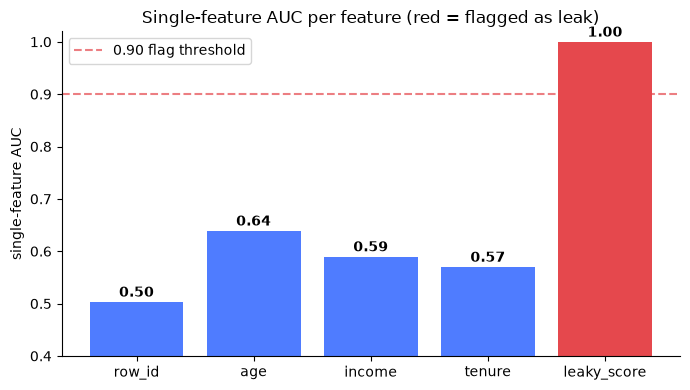

In [7]:
y = _encode_target(train_df[target]).to_numpy(dtype=float)
feat_cols = _numeric_feature_columns(train_df, target)
aucs = {c: _simple_auc(train_df[c].to_numpy(dtype=float), y) for c in feat_cols}
aucs = {c: (v if v is not None else 0.5) for c, v in aucs.items()}

names = list(aucs.keys())
vals = [aucs[c] for c in names]
colors = ["#e5484d" if v >= 0.90 else "#4f7cff" for v in vals]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(names, vals, color=colors)
ax.axhline(0.90, ls="--", color="#e5484d", alpha=0.7, label="0.90 flag threshold")
ax.set_ylim(0.4, 1.02)
ax.set_ylabel("single-feature AUC")
ax.set_title("Single-feature AUC per feature (red = flagged as leak)")
for i, v in enumerate(vals):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontweight="bold")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


<a id="try"></a>
## 7. Try your own data

Uncomment and point it at your own train/test split.

In [8]:
# import pandas as pd
# my_train = pd.read_csv("my_train.csv")
# my_test = pd.read_csv("my_test.csv")
# my_result = run_all(my_train, my_test, target="my_target_column")
# print(my_result["verdict"], my_result["summary"])
# pd.DataFrame(my_result["findings"])


---

Built by Phoebe Fu. Part of the [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) FDE portfolio.

> Heuristics can false-positive on genuinely strong features. Every finding is a prompt for human review, not an automatic verdict.